In [1]:
import pandas as pd
import sqlite3

In [2]:
df = pd.read_csv('C:/Users/mlula/Downloads/MRDM/bank+marketing classification/bank/bank-full.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,18,student,single,primary,no,1944,no,no,telephone,10,aug,122,3,-1,0,unknown,no
1,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes
2,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes
3,18,student,single,unknown,no,35,no,no,telephone,21,aug,104,2,-1,0,unknown,no
4,18,student,single,secondary,no,5,no,no,cellular,24,aug,143,2,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,93,retired,married,unknown,no,775,no,no,cellular,22,jul,860,2,177,7,success,yes
45207,93,retired,married,unknown,no,775,no,no,cellular,4,aug,476,2,13,9,success,yes
45208,94,retired,divorced,secondary,no,1234,no,no,cellular,3,mar,212,1,-1,0,unknown,no
45209,95,retired,divorced,primary,no,2282,no,no,telephone,21,apr,207,17,-1,0,unknown,yes


In [12]:
conn = sqlite3.connect('mydatabase.db')

In [13]:
# CLIENT
client = df[['age', 'job', 'marital', 'education']].copy()
client['client_id'] = client.index

# FINANCIAL
financial = df[['balance', 'housing', 'loan']].copy()
financial['client_id'] = financial.index

# CAMPAIGN
campaign = df[['contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']].copy()
campaign['client_id'] = campaign.index

# TARGET
target = df[['y']].copy()
target['client_id'] = target.index

In [14]:
client.to_sql('client', conn, if_exists='replace', index=False)
financial.to_sql('financial', conn, if_exists='replace', index=False)
campaign.to_sql('campaign', conn, if_exists='replace', index=False)
target.to_sql('target', conn, if_exists='replace', index=False)

45211

In [15]:
query = """
SELECT *
FROM client
JOIN financial USING(client_id)
JOIN campaign USING(client_id)
JOIN target USING(client_id)
"""

mrdm_df = pd.read_sql(query, conn)
mrdm_df

,age,job,marital,education,client_id,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,y
0,18,student,single,primary,0,1944,no,no,telephone,122,3,-1,0,unknown,no
1,18,student,single,unknown,1,108,no,no,cellular,167,1,-1,0,unknown,yes
2,18,student,single,primary,2,608,no,no,cellular,267,1,-1,0,unknown,yes
3,18,student,single,unknown,3,35,no,no,telephone,104,2,-1,0,unknown,no
4,18,student,single,secondary,4,5,no,no,cellular,143,2,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,93,retired,married,unknown,45206,775,no,no,cellular,860,2,177,7,success,yes
45207,93,retired,married,unknown,45207,775,no,no,cellular,476,2,13,9,success,yes
45208,94,retired,divorced,secondary,45208,1234,no,no,cellular,212,1,-1,0,unknown,no
45209,95,retired,divorced,primary,45209,2282,no,no,telephone,207,17,-1,0,unknown,yes


In [16]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,client
1,financial
2,campaign
3,target


In [17]:
import os
os.getcwd()

'C:\\Users\\mlula\\Downloads\\MRDM\\bank+marketing classification'

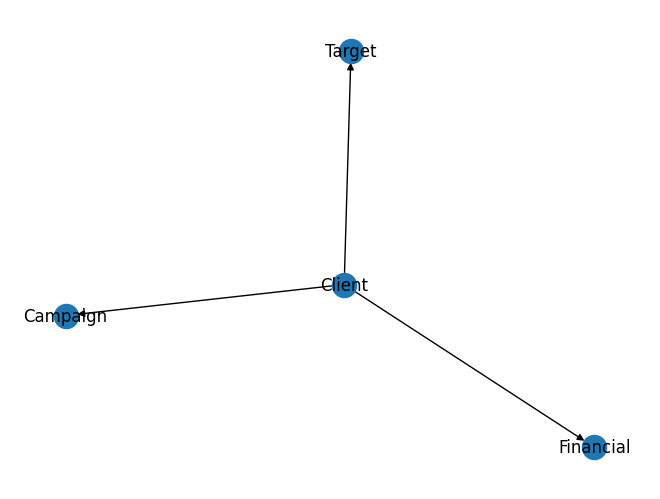

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# nodes
G.add_node("Client")
G.add_node("Financial")
G.add_node("Campaign")
G.add_node("Target")

# edges
G.add_edge("Client", "Financial")
G.add_edge("Client", "Campaign")
G.add_edge("Client", "Target")

# draw
nx.draw(G, with_labels=True)
plt.show()

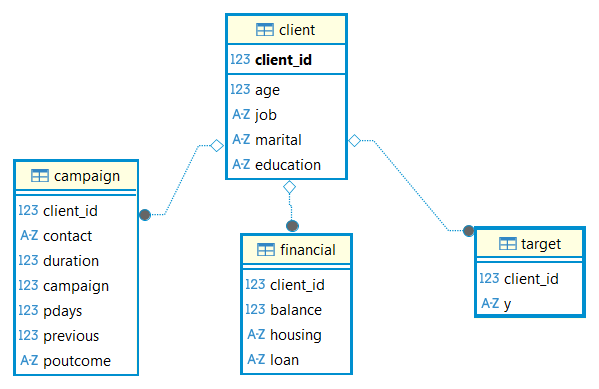

In [11]:
from IPython.display import Image

Image("mydatabasediagram.png")